# Adding more data and compare measures

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import os
from itertools import product

from tqdm import tqdm

In [2]:
# Moving to parent directory to import from CDFD and other_helpers
current_dir = os.getcwd()
os.chdir("..")
from CDFD import get_circularity, CDFD
from other_helpers import  uniform_multigraph, in_cycle_ratio, trophic_incoherence,finn_cycling_index_sparse
from scipy.sparse import lil_array, csr_array, diags_array, coo_array, identity, csr_matrix, eye
from scipy.sparse.linalg import splu
# Moving back to original directory
os.chdir(current_dir)

### migration data

In [11]:
records = []
base_dir = 'data_government'

for sub in tqdm(os.listdir(base_dir)):
    folder = os.path.join(current_dir,base_dir, sub)
    if not os.path.isdir(folder):
        continue
    if 'edges.txt' not in os.listdir(folder):
        continue

    # --- load edges only; nodes inferred automatically ---
    edges = pd.read_csv(
        os.path.join(folder,'edges.txt'),
        sep='\t', engine='python'
    )
    G = nx.DiGraph()
    for _, row in edges.iterrows():
        u, v = int(row.Src), int(row.Trg)
        G.add_edge(u, v, weight=float(row.LinkCount))

    # --- infer node list (sorted for reproducibility) ---
    nodes = sorted(G.nodes())

    # --- compute measures ---
    incoh    = trophic_incoherence(G)
    incyc    = in_cycle_ratio(G)
    W        = nx.to_numpy_array(G, nodelist=nodes, weight='weight')
    x        = W.sum(axis=0)
    # fci    = finn_cycling_index_sparse(csr_matrix(W), x)
    C1, D1   = CDFD(G, solution_method='min_cost_pulp')
    circ_max = get_circularity(C1, D1)
    C2, D2   = CDFD(G, solution_method='BFF')
    circ_bff = get_circularity(C2, D2)

    records.append({
        'folder':         sub,
        'incoherence':    incoh,
        'in_cycle_ratio': incyc,
        # 'fci':            fci,
        'circ_max':       circ_max,
        'circ_bff':       circ_bff
    })


  0%|                                                              | 0/55 [00:00<?, ?it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/a9afe427865d4b83bc19c4ff09721719-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/a9afe427865d4b83bc19c4ff09721719-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 1045 COLUMNS
At line 30977 RHS
At line 32018 BOUNDS
At line 41996 ENDATA
Problem MODEL has 1040 rows, 9977 columns and 19954 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 595 (-445) rows, 7162 (-2815) columns and 14324 (-5630) elements
Perturbing problem by 0.001% of 3 - largest nonzero change 6.0811993e-05 ( 0.0056497849%) - largest zero change 4.6850264e-05
0  Obj 530894.38 Primal inf 88408.286 (586)
86  Obj 584957.37 Primal i

  4%|█▉                                                    | 2/55 [00:01<00:33,  1.60it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/9e8317e6a5234ac0bc648f0c2581b8e8-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/9e8317e6a5234ac0bc648f0c2581b8e8-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 352 COLUMNS
At line 4544 RHS
At line 4892 BOUNDS
At line 6290 ENDATA
Problem MODEL has 347 rows, 1397 columns and 2794 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 136 (-211) rows, 876 (-521) columns and 1752 (-1042) elements
Perturbing problem by 0.001% of 3 - largest nonzero change 5.8176759e-05 ( 0.0056447641%) - largest zero change 0
0  Obj 81693.356 Primal inf 6494.8043 (135)
46  Obj 85417.332 Primal inf 927.60137 (109)
12

  7%|███▉                                                  | 4/55 [00:02<00:21,  2.37it/s]

...

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/11aae6aaa4e64cbc914fc6165b1fdb1f-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/11aae6aaa4e64cbc914fc6165b1fdb1f-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 372 COLUMNS
At line 14305 RHS
At line 14673 BOUNDS
At line 19318 ENDATA
Problem MODEL has 367 rows, 4644 columns and 9288 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 210 (-157) rows, 3135 (-1509) columns and 6270 (-3018) elements
Perturbing problem by 0.001% of 2 - largest nonzero change 5.8488022e-05 ( 0.0055962401%) - largest zero change 0
0  Obj 238472.42 Primal inf 57994.207 (209)
79  Obj 275761.92 Primal inf 9307.1015 (17

 95%|██████████████████████████████████████████████████   | 52/55 [00:49<00:01,  1.74it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/2956adb40496418e83955d06bd969838-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/2956adb40496418e83955d06bd969838-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 3590 COLUMNS
At line 156285 RHS
At line 159871 BOUNDS
At line 210770 ENDATA
Problem MODEL has 3585 rows, 50898 columns and 101796 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 1885 (-1700) rows, 39324 (-11574) columns and 78648 (-23148) elements
Perturbing problem by 0.001% of 3 - largest nonzero change 6.1408612e-05 ( 0.0056499673%) - largest zero change 4.9148156e-05
0  Obj 4029964.6 Primal inf 659995.93 (1872)
112  Obj 437400

100%|█████████████████████████████████████████████████████| 55/55 [01:24<00:00,  1.54s/it]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/c756f53359b445b886b8a791c4415d9a-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/c756f53359b445b886b8a791c4415d9a-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 270 COLUMNS
At line 6694 RHS
At line 6960 BOUNDS
At line 9102 ENDATA
Problem MODEL has 265 rows, 2141 columns and 4282 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 182 (-83) rows, 1857 (-284) columns and 3714 (-568) elements
Perturbing problem by 0.001% of 2 - largest nonzero change 5.8300522e-05 ( 0.0055948105%) - largest zero change 0
0  Obj 112142.49 Primal inf 15630.008 (179)
78  Obj 121956.3 Primal inf 1252.2002 (129)
154 

In [12]:
# build DataFrame
df_government = pd.DataFrame(records)
df_government.head()

,folder,incoherence,in_cycle_ratio,circ_max,circ_bff
0,missouri,0.160074,0.720048,0.082940,0.074211
1,southdakota,0.265364,0.855481,0.158667,0.146585
2,alaska,0.155614,0.550183,0.079233,0.067318
3,newhampshire,0.048299,0.467825,0.007456,0.007027
4,illinois,0.077096,0.753532,0.048529,0.046651


In [5]:
records_fw = []
base_dir_fw = 'data_foodweb'

for fname in tqdm(os.listdir(base_dir_fw)):
    if not fname.endswith('.txt'):
        continue
    path = os.path.join(base_dir_fw, fname)
    
    # load edges: no header, whitespace‐delim, quotes around names
    edges = pd.read_csv(
        path,
        sep=r'\s+',
        header=None,
        names=['Src','Trg','Weight'],
        engine='python'
    )
    # strip quotes
    edges['Src'] = edges['Src'].str.strip('"')
    edges['Trg'] = edges['Trg'].str.strip('"')

    # build directed graph
    G = nx.DiGraph()
    for u, v, w in zip(edges.Src, edges.Trg, edges.Weight):
        G.add_edge(u, v, weight=float(w))

    # sorted node list for matrix consistency
    nodes = sorted(G.nodes())

    # compute measures
    incoh    = trophic_incoherence(G)
    incyc    = in_cycle_ratio(G)
    W        = nx.to_numpy_array(G, nodelist=nodes, weight='weight')
    x        = W.sum(axis=0)
    # fci      = finn_cycling_index_sparse(csr_matrix(W), x)
    C1, D1   = CDFD(G, solution_method='min_cost_pulp')
    circ_max = get_circularity(C1, D1)
    C2, D2   = CDFD(G, solution_method='BFF')
    circ_bff = get_circularity(C2, D2)

    records_fw.append({
        'file':           fname,
        'incoherence':    incoh,
        'in_cycle_ratio': incyc,
        # 'fci':            fci,
        'circ_max':       circ_max,
        'circ_bff':       circ_bff
    })



  7%|████                                                  | 7/94 [00:00<00:03, 28.17it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/1a66ea721c52487d96f304eb3fe53c37-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/1a66ea721c52487d96f304eb3fe53c37-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 17 COLUMNS
At line 156 RHS
At line 169 BOUNDS
At line 216 ENDATA
Problem MODEL has 12 rows, 46 columns and 92 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 0 (-12) rows, 0 (-46) columns and 0 (-92) elements
Empty problem - 0 rows, 0 columns and 0 elements
Optimal - objective value 601.648
After Postsolve, objective 601.648, infeasibilities - dual 0 (0), primal 0 (0)
Optimal objective 601.648 - 0 iterations time 0.002, Presolve 0

 17%|█████████                                            | 16/94 [00:00<00:02, 36.20it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/d44518cb096c4e049fd3037e735a0a90-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/d44518cb096c4e049fd3037e735a0a90-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 33 COLUMNS
At line 286 RHS
At line 315 BOUNDS
At line 400 ENDATA
Problem MODEL has 28 rows, 84 columns and 168 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 13 (-15) rows, 45 (-39) columns and 90 (-78) elements
Perturbing problem by 0.001% of 2 - largest nonzero change 5.6245917e-05 ( 0.0055016409%) - largest zero change 0
0  Obj 143827.84 Primal inf 8.166126 (13)
23  Obj 143835.14
Optimal - objective value 143832.5
After Postso

 21%|███████████▎                                         | 20/94 [00:00<00:02, 35.33it/s]

...

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/6ebdfeb0ad264b89884ab003108292f6-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/6ebdfeb0ad264b89884ab003108292f6-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 20 COLUMNS
At line 132 RHS
At line 148 BOUNDS
At line 186 ENDATA
Problem MODEL has 15 rows, 37 columns and 74 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 3 (-12) rows, 6 (-31) columns and 12 (-62) elements
0  Obj 2495.225 Primal inf 0.87999731 (3)
2  Obj 2495.865
Optimal - objective value 2495.865
After Postsolve, objective 2495.865, infeasibilities - dual 0 (0), primal 0 (0)
Optimal objective 2495.865 - 2 iterations time 0.00

 90%|███████████████████████████████████████████████▉     | 85/94 [00:02<00:00, 38.48it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/564b091443f843f0ac6d7f6e7f86b258-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/564b091443f843f0ac6d7f6e7f86b258-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 28 COLUMNS
At line 260 RHS
At line 284 BOUNDS
At line 362 ENDATA
Problem MODEL has 23 rows, 77 columns and 154 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 0 (-23) rows, 0 (-77) columns and 0 (-154) elements
Empty problem - 0 rows, 0 columns and 0 elements
Optimal - objective value 178.767
After Postsolve, objective 178.767, infeasibilities - dual 0 (0), primal 0 (0)
Optimal objective 178.767 - 0 iterations time 0.002, Presolve

100%|█████████████████████████████████████████████████████| 94/94 [00:02<00:00, 36.67it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/fc57f2053ff94ce19ab06561ce0daf41-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/fc57f2053ff94ce19ab06561ce0daf41-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 23 COLUMNS
At line 255 RHS
At line 274 BOUNDS
At line 352 ENDATA
Problem MODEL has 18 rows, 77 columns and 154 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 0 (-18) rows, 0 (-77) columns and 0 (-154) elements
Empty problem - 0 rows, 0 columns and 0 elements
Optimal - objective value 265.878
After Postsolve, objective 265.878, infeasibilities - dual 0 (0), primal 0 (0)
Optimal objective 265.878 - 0 iterations time 0.002, Presolve

In [6]:
# build DataFrame
df_fw = pd.DataFrame(records_fw)
df_fw.head()

,file,incoherence,in_cycle_ratio,circ_max,circ_bff
0,FW17.txt,0.059568,0.005223,0.003062,0.003062
1,FW16.txt,0.019159,0.002948,0.002134,0.002134
2,FW14.txt,0.032310,0.001376,0.000199,0.000193
3,FW28.txt,0.028553,0.009112,0.005816,0.005816
4,FW29.txt,0.001115,0.000000,0.000000,0.000000


In [7]:
records_io = []
base_dir_io = 'data_io'

for fname in tqdm(os.listdir(base_dir_io)):
    # only CSVs for years 2014 or 2015
    # if not fname.endswith('.csv') or not ('2014' in fname or '2015' in fname):
    if not fname.endswith('.csv') or not ('2015' in fname):
        continue
    path = os.path.join(base_dir_io, fname)
    
    # load adjacency matrix, dropping the first row/column of names
    df = pd.read_csv(path, index_col=0)
    nodes = list(df.index)
    
    # build directed graph
    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    for src in nodes:
        for trg in nodes:
            w = df.at[src, trg]
            if w and w != 0:
                G.add_edge(src, trg, weight=float(w))
    
    # compute measures
    incoh    = trophic_incoherence(G)
    incyc    = in_cycle_ratio(G)
    W        = nx.to_numpy_array(G, nodelist=nodes, weight='weight')
    x        = W.sum(axis=0)
    # fci    = finn_cycling_index_sparse(csr_matrix(W), x)
    C1, D1   = CDFD(G, solution_method='min_cost_pulp')
    circ_max = get_circularity(C1, D1)
    C2, D2   = CDFD(G, solution_method='BFF')
    circ_bff = get_circularity(C2, D2)
    
    records_io.append({
        'file':           fname,
        'incoherence':    incoh,
        'in_cycle_ratio': incyc,
        # 'fci':            fci,
        'circ_max':       circ_max,
        'circ_bff':       circ_bff
    })



  0%|                                                             | 0/660 [00:00<?, ?it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/9f0c1db7025b46798a629d5ccbd68acc-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/9f0c1db7025b46798a629d5ccbd68acc-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 40 COLUMNS
At line 3161 RHS
At line 3197 BOUNDS
At line 4238 ENDATA
Problem MODEL has 35 rows, 1040 columns and 2080 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 35 (0) rows, 1040 (0) columns and 2080 (0) elements
Perturbing problem by 0.001% of 1 - largest nonzero change 1.049027e-05 ( 0.001049027%) - largest zero change 0
0  Obj 0 Primal inf 7662.8 (35)
34  Obj 3869.4284 Primal inf 1039.5 (26)
65  Obj 4347.4321 Primal inf 165

  2%|▊                                                   | 10/660 [00:00<00:08, 79.22it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/3f7c41a4d47546e99b2afd9f8244b497-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/3f7c41a4d47546e99b2afd9f8244b497-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 40 COLUMNS
At line 3506 RHS
At line 3542 BOUNDS
At line 4698 ENDATA
Problem MODEL has 35 rows, 1155 columns and 2310 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 35 (0) rows, 1155 (0) columns and 2310 (0) elements
Perturbing problem by 0.001% of 1 - largest nonzero change 1.049027e-05 ( 0.001049027%) - largest zero change 0
0  Obj 0 Primal inf 32846.2 (35)
33  Obj 20037.053 Primal inf 1165.1 (20)
64  Obj 20282.555 Primal inf 7.

  3%|█▋                                                  | 21/660 [00:00<00:08, 75.39it/s]

...

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/e19c70418fc9442299e3803fed7bdd8b-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/e19c70418fc9442299e3803fed7bdd8b-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 40 COLUMNS
At line 3440 RHS
At line 3476 BOUNDS
At line 4610 ENDATA
Problem MODEL has 35 rows, 1133 columns and 2266 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 35 (0) rows, 1133 (0) columns and 2266 (0) elements
Perturbing problem by 0.001% of 1 - largest nonzero change 1.049027e-05 ( 0.001049027%) - largest zero change 0
0  Obj 0 Primal inf 190378.6 (35)
31  Obj 93920.516 Primal inf 29331.3 (29)
64  Obj 97598.358 Primal inf 

 95%|███████████████████████████████████████████████▌  | 628/660 [00:04<00:00, 172.17it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/1e19de15349c452eacc519aaca01ff2b-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/1e19de15349c452eacc519aaca01ff2b-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 40 COLUMNS
At line 3608 RHS
At line 3644 BOUNDS
At line 4834 ENDATA
Problem MODEL has 35 rows, 1189 columns and 2378 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 35 (0) rows, 1189 (0) columns and 2378 (0) elements
Perturbing problem by 0.001% of 1 - largest nonzero change 1.049027e-05 ( 0.001049027%) - largest zero change 0
0  Obj 0 Primal inf 67768.2 (35)
39  Obj 40638.119 Primal inf 1840.5 (18)
68  Obj 40769.321
Optimal - obj

100%|██████████████████████████████████████████████████| 660/660 [00:04<00:00, 154.75it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/2232410f2e144b2886169eb7fe6f6e90-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/2232410f2e144b2886169eb7fe6f6e90-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 40 COLUMNS
At line 3290 RHS
At line 3326 BOUNDS
At line 4410 ENDATA
Problem MODEL has 35 rows, 1083 columns and 2166 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 35 (0) rows, 1083 (0) columns and 2166 (0) elements
Perturbing problem by 0.001% of 1 - largest nonzero change 1.049027e-05 ( 0.001049027%) - largest zero change 0
0  Obj 0 Primal inf 10893.8 (35)
40  Obj 5719.9465 Primal inf 1423 (22)
70  Obj 5993.147
Optimal - object

In [8]:
# build DataFrame
df_io = pd.DataFrame(records_io)
df_io.head()

,file,incoherence,in_cycle_ratio,circ_max,circ_bff
0,2015_EST.csv,0.735977,1.0,0.603001,0.524962
1,2015_HUN.csv,0.751682,1.0,0.613845,0.543513
2,2015_CHN.csv,0.666473,1.0,0.521690,0.452005
3,2015_NOR.csv,0.781214,1.0,0.648406,0.589075
4,2015_SWE.csv,0.808358,1.0,0.677457,0.609396


In [9]:
records_sarafu = []
base_dir_sf = 'data_sarafu'

for fname in tqdm(os.listdir(base_dir_sf)):
    # only process Pajek .net files matching the monthly pattern
    if not (fname.startswith('sarafu_reg_') and fname.endswith('.net')):
        continue

    # extract month from filename: 'sarafu_reg_YYYY-MM.net'
    month = fname.replace('sarafu_reg_', '').replace('.net', '')

    # load directed graph
    path = os.path.join(base_dir_sf, fname)
    G = nx.DiGraph(nx.read_pajek(path, encoding='UTF-8'))

    # compute metrics
    incoh    = trophic_incoherence(G)
    incyc    = in_cycle_ratio(G)
    W        = nx.to_numpy_array(G, weight='weight')
    x        = W.sum(axis=0)
    # fci      = finn_cycling_index_sparse(csr_matrix(W), x)
    C1, D1   = CDFD(G, solution_method='min_cost_pulp')
    circ_max = get_circularity(C1, D1)
    C2, D2   = CDFD(G, solution_method='BFF')
    circ_bff = get_circularity(C2, D2)

    # collect results
    records_sarafu.append({
        'month':          month,
        'num_nodes':      G.number_of_nodes(),
        'avg_weight':     W.sum() / G.number_of_nodes(),
        'avg_degree':     G.number_of_edges() / G.number_of_nodes(),
        'incoherence':    incoh,
        'in_cycle_ratio': incyc,
        # 'fci':            fci,
        'circ_max':       circ_max,
        'circ_bff':       circ_bff
    })

# build DataFrame and save
df_sarafu = pd.DataFrame.from_dict(records_sarafu)
df_sarafu.head()

  0%|                                                              | 0/18 [00:00<?, ?it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/e282b5a7ff244b1cb4099f1637b3e4c7-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/e282b5a7ff244b1cb4099f1637b3e4c7-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 4339 COLUMNS
At line 28850 RHS
At line 33185 BOUNDS
At line 41356 ENDATA
Problem MODEL has 4334 rows, 8170 columns and 16340 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 836 (-3498) rows, 3681 (-4489) columns and 7361 (-8979) elements
Perturbing problem by 0.001% of 3 - largest nonzero change 6.5494511e-05 ( 0.0056462065%) - largest zero change 4.3588492e-05
0  Obj 4341945.8 Primal inf 853490.26 (795)
91  Obj 4741238.3 Primal i

  6%|███                                                   | 1/18 [00:01<00:20,  1.18s/it]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/eeef4d12324d4842b75e2e1d6950ca12-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/eeef4d12324d4842b75e2e1d6950ca12-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 3760 COLUMNS
At line 25196 RHS
At line 28952 BOUNDS
At line 36098 ENDATA
Problem MODEL has 3755 rows, 7145 columns and 14290 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 826 (-2929) rows, 3480 (-3665) columns and 6960 (-7330) elements
Perturbing problem by 0.001% of 3 - largest nonzero change 6.1443008e-05 ( 0.0056462065%) - largest zero change 2.6041773e-05
0  Obj 1352285 Primal inf 519170.52 (770)
91  Obj 1611135.7 Primal inf

 11%|██████                                                | 2/18 [00:02<00:17,  1.10s/it]

...

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/3f1941359f434f3fb2fb95f336e50ac0-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/3f1941359f434f3fb2fb95f336e50ac0-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 7753 COLUMNS
At line 66512 RHS
At line 74261 BOUNDS
At line 93848 ENDATA
Problem MODEL has 7748 rows, 19586 columns and 39172 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 2137 (-5611) rows, 12440 (-7146) columns and 24879 (-14293) elements
Perturbing problem by 0.001% of 3 - largest nonzero change 6.2002651e-05 ( 0.0056499673%) - largest zero change 4.5953785e-05
0  Obj 3208142.5 Primal inf 3881430.7 (2089) Dual inf 0.99994452 

 83%|████████████████████████████████████████████▏        | 15/18 [00:33<00:10,  3.40s/it]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/46e9d1c4efec4bce83af2eb4f71330f6-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/46e9d1c4efec4bce83af2eb4f71330f6-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 4278 COLUMNS
At line 35257 RHS
At line 39531 BOUNDS
At line 49858 ENDATA
Problem MODEL has 4273 rows, 10326 columns and 20652 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 1138 (-3135) rows, 6696 (-3630) columns and 13391 (-7261) elements
Perturbing problem by 0.001% of 3 - largest nonzero change 6.4250206e-05 ( 0.0056497849%) - largest zero change 3.9509361e-05
0  Obj 3825368.8 Primal inf 2783084.8 (1091)
97  Obj 5069811.7 Prim

100%|█████████████████████████████████████████████████████| 18/18 [00:35<00:00,  1.96s/it]


,month,num_nodes,avg_weight,avg_degree,incoherence,in_cycle_ratio,circ_max,circ_bff
0,2021-01,4334,3094.047806,1.885095,0.706940,0.863928,0.637009,0.630698
1,2021-03,3755,1123.982450,1.902796,0.692699,0.814893,0.608977,0.593788
2,2021-02,5437,1302.916103,1.994114,0.713139,0.846464,0.651334,0.640947
3,2021-05,5459,753.150714,1.960432,0.507464,0.660020,0.427147,0.419812
4,2021-04,4621,882.616555,1.732309,0.712270,0.800449,0.652281,0.643421


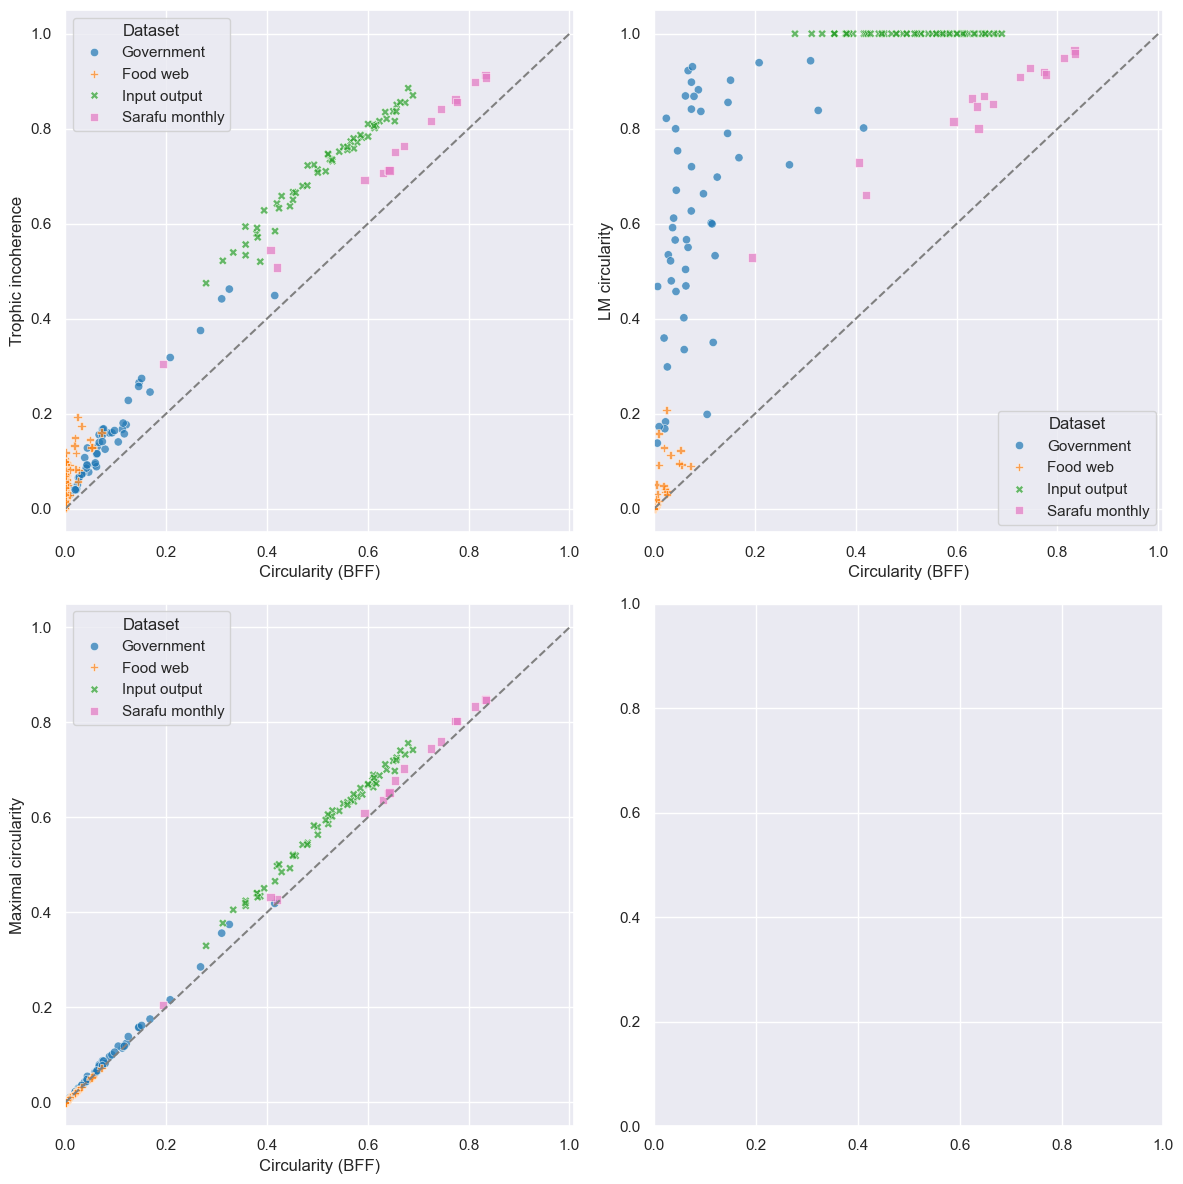

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt


# Tag each dataset
df_government['dataset']    = 'Government'
df_fw['dataset'] = 'Food web'
df_io['dataset'] = 'Input output'
df_sarafu['dataset'] ='Sarafu monthly'
# Combine into one DataFrame
combined = pd.concat([df_government, df_fw, df_io,df_sarafu], ignore_index=True)
sns.set_theme(style="darkgrid")
# measures = ['incoherence', 'in_cycle_ratio', 'circ_max','fci']
measures = ['incoherence', 'in_cycle_ratio', 'circ_max']
measures_mapping= {'incoherence':'Trophic incoherence', 'in_cycle_ratio':'LM circularity', 'circ_max':'Maximal circularity','fci':"Finn cycle index"}
palette = {'Government':'tab:blue','Food web':'tab:orange', 'Input output':'tab:green','Sarafu monthly':'tab:pink'}
markers = {"Government" : "o", "Food web": "P", "Input output": "X","Sarafu monthly":"s"}
# Create 2×2 grid of scatter plots


fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for ax, measure in zip(axes, measures):
    sns.scatterplot(
        data=combined,
        x='circ_bff',
        y=measure,
        hue='dataset',
        style='dataset',
        palette=palette,
        alpha=0.7,
        markers = markers,
        ax=ax
    )
    # y = x reference line
    ax.plot([0, 1], [0, 1], ls='--', c='gray')
    ax.set_xlim(0, 1.01)
    # ax.set_ylim(-0.1, 1.01)
    ax.set_xlabel('Circularity (BFF)')
    ax.set_ylabel(measures_mapping[measure])
    ax.legend(title='Dataset')

plt.tight_layout()
plt.show()